# Credit Card Fraud Detection Model

The goal is to create a model to detect fraudulent credit card transactions. The model is built based on an synthetic kaggle dataset. \
Link to the data: https://www.kaggle.com/datasets/bhadramohit/credit-card-fraud-detection?select=credit_card_fraud_dataset.csv

In [1]:
import numpy as np
import time

# data manipulation
import pandas as pd

# visualization
import matplotlib.pyplot as plt 
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Model Selection
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate

# Models 
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [2]:
df = pd.read_csv('credit_card.csv')
df.columns = [col.lower() for col in df.columns]

## Basic data info

In [3]:
df.head()

,transactionid,transactiondate,amount,merchantid,transactiontype,location,isfraud
0,1,2024-04-03 14:15:35.462794,4189.27,688,refund,San Antonio,0
1,2,2024-03-19 13:20:35.462824,2659.71,109,refund,Dallas,0
2,3,2024-01-08 10:08:35.462834,784.00,394,purchase,New York,0
3,4,2024-04-13 23:50:35.462850,3514.40,944,purchase,Philadelphia,0
4,5,2024-07-12 18:51:35.462858,369.07,475,purchase,Phoenix,0


In [4]:
df.describe()

,transactionid,amount,merchantid,isfraud
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,2497.092666,501.676070,0.010000
std,28867.657797,1442.415999,288.715868,0.099499
min,1.000000,1.050000,1.000000,0.000000
25%,25000.750000,1247.955000,252.000000,0.000000
50%,50000.500000,2496.500000,503.000000,0.000000
75%,75000.250000,3743.592500,753.000000,0.000000
max,100000.000000,4999.770000,1000.000000,1.000000


In [5]:
df[['transactiondate', 'transactiontype', 'location']].describe()

,transactiondate,transactiontype,location
count,100000,100000,100000
unique,100000,2,10
top,2024-04-03 14:15:35.462794,refund,Chicago
freq,1,50131,10193


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   transactionid    100000 non-null  int64  
 1   transactiondate  100000 non-null  object 
 2   amount           100000 non-null  float64
 3   merchantid       100000 non-null  int64  
 4   transactiontype  100000 non-null  object 
 5   location         100000 non-null  object 
 6   isfraud          100000 non-null  int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 5.3+ MB


First observation: data is very unbalanced (1% of the transactions are fraud)

In [7]:
df.head()

,transactionid,transactiondate,amount,merchantid,transactiontype,location,isfraud
0,1,2024-04-03 14:15:35.462794,4189.27,688,refund,San Antonio,0
1,2,2024-03-19 13:20:35.462824,2659.71,109,refund,Dallas,0
2,3,2024-01-08 10:08:35.462834,784.00,394,purchase,New York,0
3,4,2024-04-13 23:50:35.462850,3514.40,944,purchase,Philadelphia,0
4,5,2024-07-12 18:51:35.462858,369.07,475,purchase,Phoenix,0


## EDA (Univariate and Bivariate)

### Amount

#### Distribution Visually

Text(0.5, 0, 'isfraud')

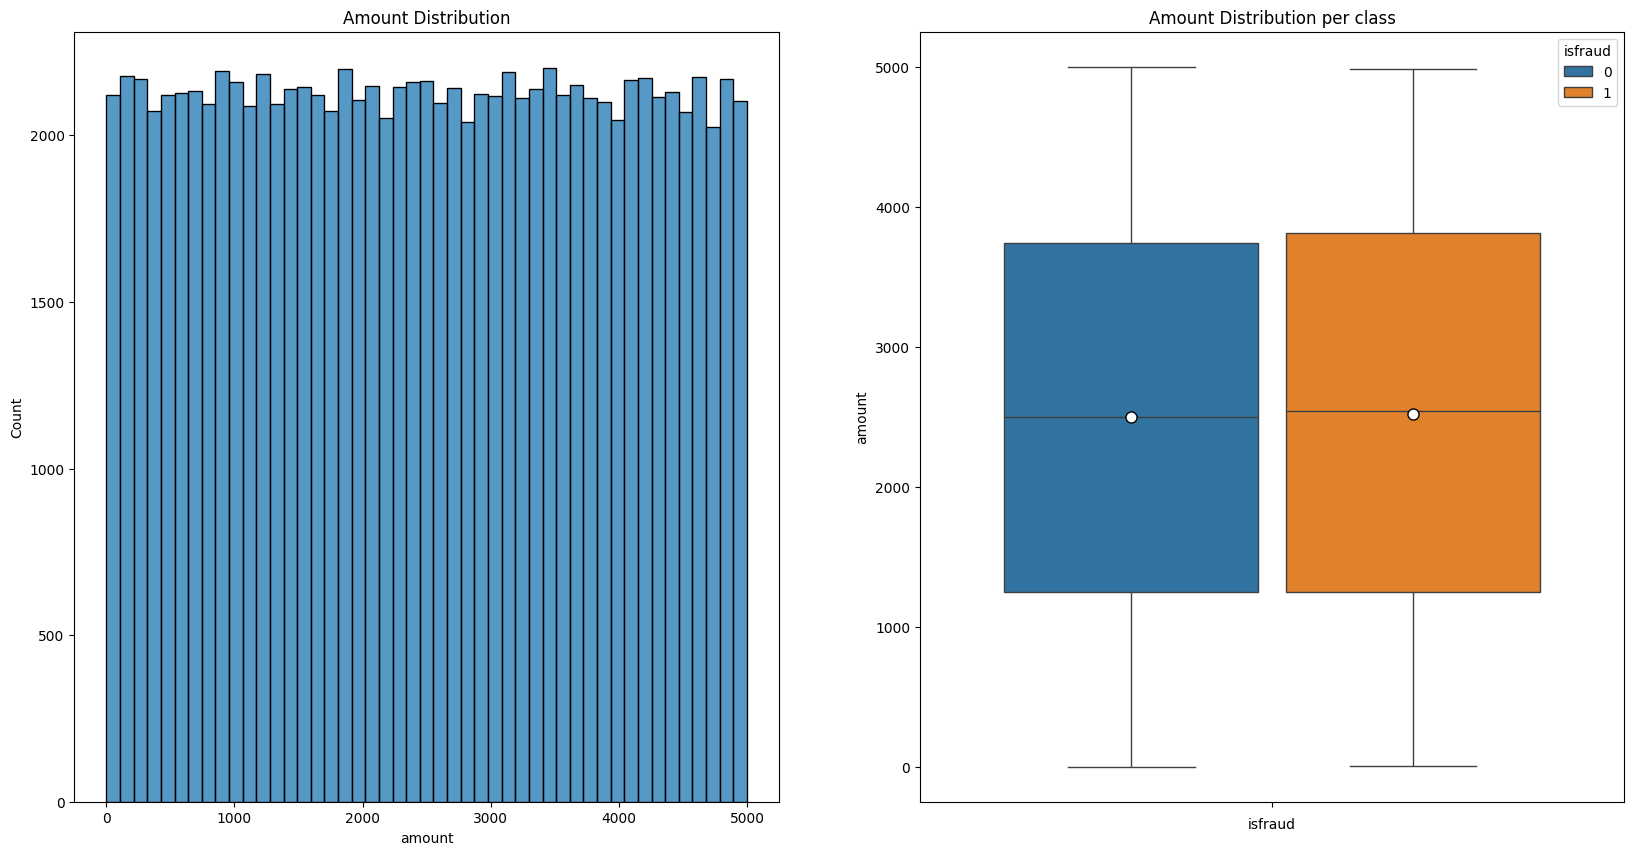

In [8]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(20,10))
ax1.set_title('Amount Distribution')
ax2.set_title('Amount Distribution per class')
sns.histplot(data=df, x='amount', ax=ax1)
sns.boxplot(data=df, 
            y='amount', 
            hue='isfraud', 
            showmeans=True, 
            meanprops={
                "marker": "o", 
            "markerfacecolor": "white", 
            "markeredgecolor": "black",
            "markersize": "8"
            },
            gap=0.1, 
            ax=ax2)
ax2.set_xlabel('isfraud')

#### Distribution Statistically

In [9]:
print(f"Mean: {df.amount.mean()}")
print(f"Median: {df.amount.median()}")
print(f"STD: {df.amount.std()}")
print(f"Skew: {df.amount.skew()}")
print(f"Kurtosis: {df.amount.kurtosis()}")

Mean: 2497.0926656
Median: 2496.5
STD: 1442.4159985963565
Skew: 0.001643312258608711
Kurtosis: -1.1995193120072651


Do fraud transactions have different statistical properties than legitimate ones?

In [10]:
df.groupby('isfraud')['amount'].describe()

,count,mean,std,min,25%,50%,75%,max
isfraud,,,,,,,,
0,99000.0,2496.88992,1442.257175,1.05,1247.9550,2495.61,3742.855,4999.77
1,1000.0,2517.16444,1458.643653,5.56,1249.2775,2543.43,3813.850,4985.88


No they don't. \
Now bin the amount to detect if fraud might cluster slightly in specific ranges.

In [11]:
df['amount_bin'] = pd.cut(df.amount, bins=10)
bin_analysis = df.groupby('amount_bin', observed=False)['isfraud'].agg(['count', 'sum', 'mean'])
bin_analysis

,count,sum,mean
amount_bin,,,
"(-3.949, 500.922]",10041,101,0.010059
"(500.922, 1000.794]",10058,88,0.008749
"(1000.794, 1500.666]",9997,118,0.011804
"(1500.666, 2000.538]",9986,90,0.009013
"(2000.538, 2500.41]",9996,92,0.009204
"(2500.41, 3000.282]",9945,104,0.010458
"(3000.282, 3500.154]",10097,97,0.009607
"(3500.154, 4000.026]",9938,94,0.009459
"(4000.026, 4499.898]",10007,116,0.011592


#### Conclusion

Fraud rate per bin is very close to the global fraud rate (~1%). \
Knowing the transaction amount most likely doesn't change the fraud probability. \
On its own, amount will likely contribute very little predictive power to the model.

### MerchantID

#### Basic Structure

In [12]:
print(f"Unique Merchants: {df['merchantid'].nunique()}")
print('Most frequent merchants: ')
print(df['merchantid'].value_counts().head(20))

Unique Merchants: 1000
Most frequent merchants: 
merchantid
461    149
188    134
192    129
517    128
820    126
20     125
958    124
698    124
677    123
17     122
878    122
994    122
212    122
505    121
349    121
984    121
59     121
61     121
743    121
813    120
Name: count, dtype: int64


#### Fraud Rate Per Merchant
Do some merchants have significantly higher fraud rates than others? 

In [13]:
rate_per_merchant = df.groupby('merchantid')['isfraud'].agg(['count', 'sum', 'mean']).reset_index().rename(columns={'mean':'fraud_rate'})
rate_per_merchant = rate_per_merchant.sort_values('fraud_rate', ascending=False)
rate_per_merchant

,merchantid,count,sum,fraud_rate
639,640,86,5,0.058140
155,156,103,5,0.048544
582,583,106,5,0.047170
658,659,88,4,0.045455
938,939,91,4,0.043956
...,...,...,...,...
631,632,104,0,0.000000
628,629,92,0,0.000000
205,206,88,0,0.000000
626,627,82,0,0.000000


**Observation:** \
There are merchants with higher fraud rates but this can be random noise since every merchant counts ~100 transactions. \
Since we would expect ~1% frauds this could be noise. 
Can not conclude that certain merchants are actually riskier.

**Question:** \
How are the fraud rates distributed? 

Text(0.5, 0, 'Fraud Rate')

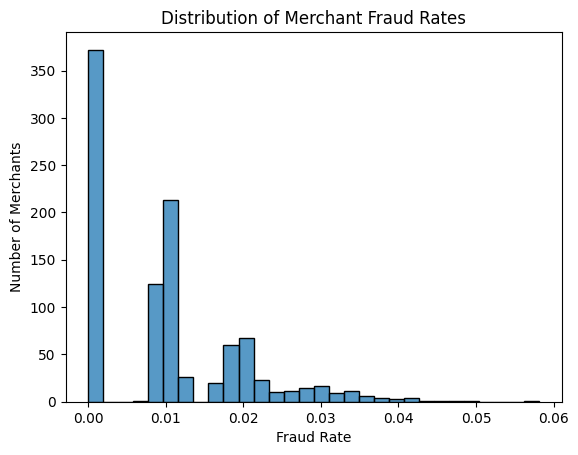

In [14]:
sns.histplot(data=rate_per_merchant, x='fraud_rate', bins=30)
plt.title('Distribution of Merchant Fraud Rates')
plt.ylabel('Number of Merchants')
plt.xlabel('Fraud Rate')

**Observation:**
Fraud rates are most likely noise since this variation is pretty close to what would be expected if fraud rates are random noise

#### Conclusion
MerchantID does not appear to contian meaningful fraud signal in this dataset.

### TransactionType

#### Basic Structure
What transaction types do we have? How often do they appear?

In [15]:
df.transactiontype.value_counts()

transactiontype
refund      50131
purchase    49869
Name: count, dtype: int64

#### Fraud Rate Per Transaction Type
Does fraud occur more often in refunds or purchases? 

In [16]:
fraud_rate = df.groupby('transactiontype')['isfraud'].agg(['count', 'sum', 'mean']).reset_index().rename(columns={'mean': 'fraud_rate'})
fraud_rate

,transactiontype,count,sum,fraud_rate
0,purchase,49869,493,0.009886
1,refund,50131,507,0.010114


#### Conclusion
This also adds little information to a fraud detection model since fraud rates are equally distributed across the two categories.

### Location

#### Basic Structure

In [17]:
df.location.value_counts()

location
Chicago         10193
San Diego       10111
Dallas          10076
San Antonio     10062
New York         9993
Houston          9991
Phoenix          9960
Los Angeles      9936
Philadelphia     9873
San Jose         9805
Name: count, dtype: int64

**Observation:** \
Categories are barely evenly distributed

#### Fraud Rate Per Location
Is fraud more likely in some locations? 

In [18]:
fraud_rate_location = df.groupby('location')['isfraud'].agg(['count', 'sum', 'mean']).reset_index().rename(columns={'mean':'fraud_rate'})
fraud_rate_location

,location,count,sum,fraud_rate
0,Chicago,10193,95,0.009320
1,Dallas,10076,99,0.009825
2,Houston,9991,105,0.010509
3,Los Angeles,9936,95,0.009561
4,New York,9993,116,0.011608
5,Philadelphia,9873,90,0.009116
6,Phoenix,9960,99,0.009940
7,San Antonio,10062,99,0.009839
8,San Diego,10111,115,0.011374
9,San Jose,9805,87,0.008873


#### Conclusion 
Fraud seems uniformly distributed across all locations and will also add little information as a single feature for the model

### TransactionDate

#### Data Preparation

In [19]:
# Split the TransactionDate column
# convert to datetime
df['transactiondate'] = pd.to_datetime(df['transactiondate'])
# extract components
df['year'] = df['transactiondate'].dt.year
df['month'] = df['transactiondate'].dt.month
df['day'] = df['transactiondate'].dt.day
df['hour'] = df['transactiondate'].dt.hour
df['min'] = df['transactiondate'].dt.minute
df['sec'] = df['transactiondate'].dt.second
df['weekday'] = df['transactiondate'].dt.day_name()

isFraud = df['isfraud']
# drop TransactionDate and TransactionID and IsFraud columns
df= df.drop(columns=['transactionid', 'isfraud'])
# insert IsFraud at the end of the dataframe
df['isfraud'] = isFraud

# convert column names to lowercase 
df.columns = [col.lower() for col in df.columns]
# drop amount_bin
df = df.drop(columns='amount_bin')
df

,transactiondate,amount,merchantid,transactiontype,location,year,month,day,hour,min,sec,weekday,isfraud
0,2024-04-03 14:15:35.462794,4189.27,688,refund,San Antonio,2024,4,3,14,15,35,Wednesday,0
1,2024-03-19 13:20:35.462824,2659.71,109,refund,Dallas,2024,3,19,13,20,35,Tuesday,0
2,2024-01-08 10:08:35.462834,784.00,394,purchase,New York,2024,1,8,10,8,35,Monday,0
3,2024-04-13 23:50:35.462850,3514.40,944,purchase,Philadelphia,2024,4,13,23,50,35,Saturday,0
4,2024-07-12 18:51:35.462858,369.07,475,purchase,Phoenix,2024,7,12,18,51,35,Friday,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,2024-06-07 00:57:36.027591,1057.29,289,refund,San Antonio,2024,6,7,0,57,36,Friday,0
99996,2023-10-22 23:12:36.027594,297.25,745,refund,San Antonio,2023,10,22,23,12,36,Sunday,0
99997,2024-05-31 19:27:36.027597,3448.56,690,purchase,San Antonio,2024,5,31,19,27,36,Friday,0
99998,2024-10-18 09:43:36.027601,3750.79,644,purchase,Philadelphia,2024,10,18,9,43,36,Friday,0


#### Weekday
Analyse fraud rate per weekday

In [20]:
weekday_rate = df.groupby('weekday')['isfraud'].agg(['count', 'sum', 'mean'])
weekday_rate

,count,sum,mean
weekday,,,
Friday,14307,141,0.009855
Monday,14100,148,0.010496
Saturday,14556,125,0.008588
Sunday,14375,163,0.011339
Thursday,14267,143,0.010023
Tuesday,14145,129,0.009120
Wednesday,14250,151,0.010596


#### Seconds
Analyse fraud rate per second

In [21]:
second_rate = df.groupby('sec')['isfraud'].agg(['count', 'sum', 'mean'])
second_rate

,count,sum,mean
sec,,,
35,93564,943,0.010079
36,6436,57,0.008856


#### Minutes
Analyse fraud rate per minute

In [22]:
minute_rate = df.groupby('min')['isfraud'].agg(['count', 'sum', 'mean'])
minute_rate

,count,sum,mean
min,,,
0,1659,8,0.004822
1,1620,15,0.009259
2,1688,16,0.009479
3,1693,20,0.011813
4,1648,14,0.008495
5,1627,19,0.011678
6,1623,16,0.009858
7,1657,17,0.010260
8,1654,20,0.012092


#### Hours
Analyse fraud rate per hour

In [23]:
hour_rate = df.groupby('hour')['isfraud'].agg(['count', 'sum', 'mean'])
hour_rate

,count,sum,mean
hour,,,
0,4187,47,0.011225
1,4153,52,0.012521
2,4105,38,0.009257
3,4133,45,0.010888
4,4255,47,0.011046
5,4145,38,0.009168
6,4268,43,0.010075
7,4126,44,0.010664
8,4096,51,0.012451


#### Days
Analyse fraud rate per day

In [24]:
day_rate = df.groupby('day')['isfraud'].agg(['count', 'sum', 'mean'])
day_rate

,count,sum,mean
day,,,
1,3231,32,0.009904
2,3339,29,0.008685
3,3316,30,0.009047
4,3186,31,0.009730
5,3126,25,0.007997
6,3329,35,0.010514
7,3289,45,0.013682
8,3362,40,0.011898
9,3324,37,0.011131


#### Months
Analyse fraud rate per month

In [25]:
month_rate = df.groupby('month')['isfraud'].agg(['count', 'sum', 'mean'])
month_rate

,count,sum,mean
month,,,
1,8371,96,0.011468
2,7891,96,0.012166
3,8530,90,0.010551
4,8275,70,0.008459
5,8499,75,0.008825
6,8121,67,0.008250
7,8578,95,0.011075
8,8379,90,0.010741
9,8302,88,0.010600


#### Years
Analyse fraud rate per month

In [26]:
year_rate = df.groupby('year')['isfraud'].agg(['count', 'sum', 'mean'])
year_rate

,count,sum,mean
year,,,
2023,19551,180,0.009207
2024,80449,820,0.010193


#### Conclusion
There is no signal in the transaction date. There are slight fluctuations but these most likely occure due to randomness.

## EDA (Multivariate)

### TransactionType + Location
Is there a fraud pattern in transaction types in different locations?

In [27]:
grouped = df.groupby(['transactiontype', 'location'])['isfraud'].mean()
print(grouped.sort_values(ascending=False))

transactiontype  location    
purchase         Houston         0.012412
refund           San Diego       0.011970
                 Dallas          0.011776
purchase         New York        0.011637
refund           New York        0.011579
                 Phoenix         0.010932
                 San Antonio     0.010789
purchase         San Diego       0.010768
                 Philadelphia    0.010178
refund           Los Angeles     0.009885
purchase         San Jose        0.009576
                 Chicago         0.009351
refund           Chicago         0.009290
purchase         Los Angeles     0.009225
                 Phoenix         0.008927
                 San Antonio     0.008899
refund           Houston         0.008607
                 San Jose        0.008168
                 Philadelphia    0.008021
purchase         Dallas          0.007896
Name: isfraud, dtype: float64


There is no significant signal in the combination of transactiontype and location. 

### TransactionType + Hour 

In [28]:
grouped = df.groupby(['transactiontype', 'hour'])['isfraud'].agg(['mean', 'count']).reset_index()
print(grouped.sort_values(by='mean', ascending=False)[:10])

   transactiontype  hour      mean  count
8         purchase     8  0.015904   2075
18        purchase    18  0.013470   2153
1         purchase     1  0.013391   2091
42          refund    18  0.012579   2067
33          refund     9  0.012249   2041
7         purchase     7  0.012030   1995
28          refund     4  0.011939   2094
25          refund     1  0.011639   2062
0         purchase     0  0.011612   2153
34          refund    10  0.011426   2188


### TransactionType + MerchantID

In [29]:
grouped = df.groupby(['transactiontype', 'merchantid'])['isfraud'].agg(['mean', 'count']).reset_index()
print(grouped.sort_values(by='mean', ascending=False)[:10])

     transactiontype  merchantid      mean  count
567         purchase         568  0.081633     49
155         purchase         156  0.076923     39
1826          refund         827  0.072727     55
658         purchase         659  0.071429     42
1874          refund         875  0.071429     42
1366          refund         367  0.070175     57
1277          refund         278  0.066667     45
746         purchase         747  0.065217     46
1639          refund         640  0.063830     47
788         purchase         789  0.062500     48


It seems like there are stronger fraud rates for some of the mercants but due to the small sample size this could also be very likely due tot randomnes.

### TransactionType + Amount

<Axes: xlabel='amount', ylabel='transactiontype_fraud'>

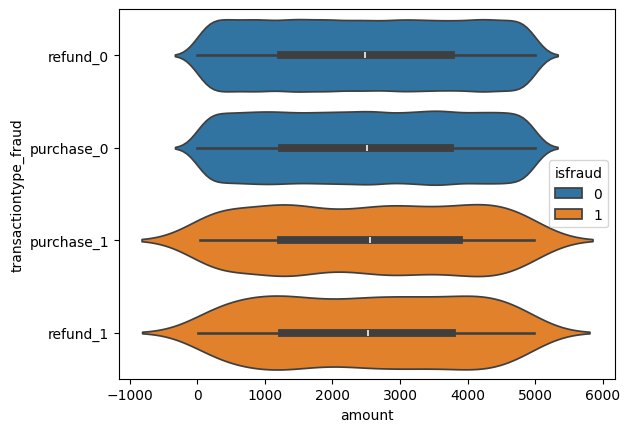

In [30]:
# create a dummy column so that we can compare the fraudulent refunds and fraudulent purchases
df_dummy = df.copy()
df_dummy['transactiontype_fraud'] = df['transactiontype'].astype(str) + '_' + df['isfraud'].astype(str)
sns.violinplot(data=df_dummy, x='amount', y='transactiontype_fraud', hue='isfraud' )

There is no significant signal in the combination with the TransactionType column.

### Amount + MerchantID

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [Text(0, 0, '17'),
  Text(1, 0, '20'),
  Text(2, 0, '59'),
  Text(3, 0, '61'),
  Text(4, 0, '188'),
  Text(5, 0, '192'),
  Text(6, 0, '212'),
  Text(7, 0, '349'),
  Text(8, 0, '461'),
  Text(9, 0, '505'),
  Text(10, 0, '517'),
  Text(11, 0, '677'),
  Text(12, 0, '698'),
  Text(13, 0, '743'),
  Text(14, 0, '813'),
  Text(15, 0, '820'),
  Text(16, 0, '878'),
  Text(17, 0, '958'),
  Text(18, 0, '984'),
  Text(19, 0, '994')])

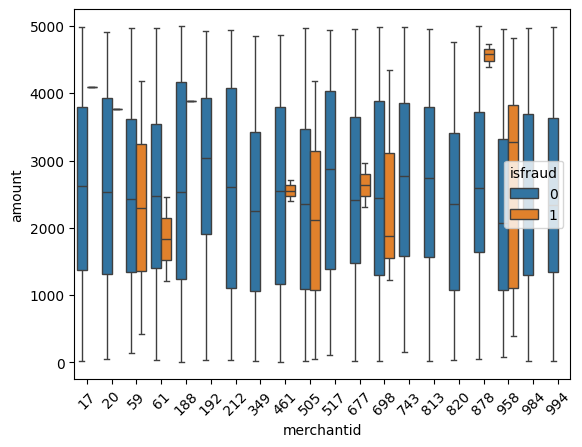

In [46]:
# Filter for the top 20 merchants by transaction volume
top_merchants = df['merchantid'].value_counts().index[:20]
subset = df[df['merchantid'].isin(top_merchants)]
sns.boxplot(data=subset, x='merchantid', y='amount', hue='isfraud')
plt.xticks(rotation=45)

In [48]:
subset.groupby(['merchantid', 'isfraud'])['isfraud'].count()

merchantid  isfraud
17          0          121
            1            1
20          0          124
            1            1
59          0          119
            1            2
61          0          119
            1            2
188         0          133
            1            1
192         0          129
212         0          122
349         0          121
461         0          147
            1            2
505         0          119
            1            2
517         0          128
677         0          121
            1            2
698         0          121
            1            3
743         0          121
813         0          120
820         0          126
878         0          119
            1            3
958         0          119
            1            5
984         0          121
994         0          122
Name: isfraud, dtype: int64

Although it looks like there are significant differences in the amount of fradulent transactions for the different merchants this is due to the small number of fraudulent samples for each merchant. 

### Amount + Location

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'San Antonio'),
  Text(1, 0, 'Dallas'),
  Text(2, 0, 'New York'),
  Text(3, 0, 'Philadelphia'),
  Text(4, 0, 'Phoenix'),
  Text(5, 0, 'Chicago'),
  Text(6, 0, 'San Jose'),
  Text(7, 0, 'San Diego'),
  Text(8, 0, 'Houston'),
  Text(9, 0, 'Los Angeles')])

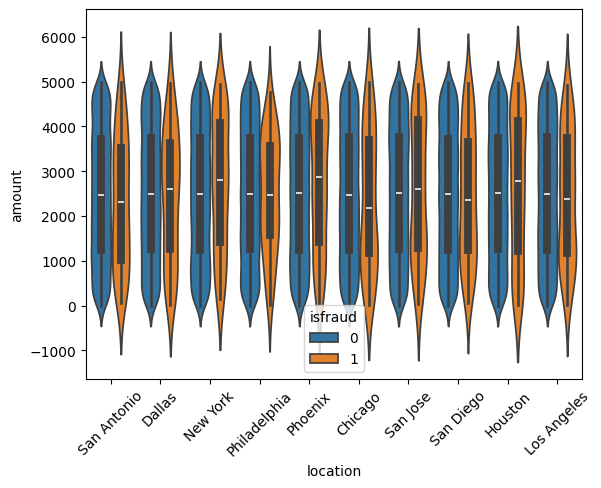

In [50]:
sns.violinplot(data=df, x='location', y='amount', hue='isfraud')
plt.xticks(rotation=45)

## Model

In [31]:
# prepare data
# don't use transaction date since this is already split up
# don't use merchantid since we have 1000 merchants
X = df.drop(columns=['transactiondate','merchantid', 'isfraud'])
y = df['isfraud']

# Create list with numerical and categorical columns
num_cols = X.select_dtypes(include=['int64', 'int32', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

### Preprocessing
Create one preprocessor for the XGBoost and the RandomForest model. Categorical columns are one-hot-encoded.

In [32]:
preprocessor = ColumnTransformer([
    ('num', 'passthrough', num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

### Define Model


In [33]:
model = Pipeline([
        ('preprocessing', preprocessor),
        ('model', XGBClassifier(
            eval_metric='logloss',
            scale_pos_weight=99))
        ])

### Train Test Split
Split the data into a train set and a test set. Use stratification to preserve the ratio of fraud in the training set and the testing set.

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2, 
    stratify=y, 
    random_state=12
)

### Evaluation Metrics
Use stratifiedKFold Cross-Validation since the data is highly inbalanced. \
Use Accuracy, Precision, Recall and F1 score. \
Accuracy is probably bad since dataset is unbalanced.

In [35]:
scoring = ['accuracy', 'precision', 'recall', 'f1']

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=12)

### Train And Evaluate Model

In [36]:
# Cross Validation

start = time.time()
scores = cross_validate(
    model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring
)
    
end = time.time()
calc_time = end-start

results = {score: [scores[f"test_{score}"].mean()] for score in scoring}
results=pd.DataFrame(results, index=['mean'])
# Results
print(f"Calculation time: {round(calc_time, 2)} seconds")
results

Calculation time: 0.96 seconds


,accuracy,precision,recall,f1
mean,0.949188,0.010521,0.04375,0.016954


### Conclusion

- Accuracy is high (95%) since there were only 1% fraudulent transactions in the dataset, so the high accuracy is due to the high amount of True Negatives. So this metric is not reliable in this case.
- Precision is very bad (only 1% of flagged transactions were flagged correctly). This confirms the assumption that accuracy is a bad metric in this case.
- Recall is also bad. Of all fraud cases only 4.4% were detected.
- F1 Score confirms the bad precision and recall

**Overall:** \
The model is still very bad in correctly predicting fraudulent transactions. This is probably due to the fact that the synthetic data is very balanced for the single columns and contains almost no signal. Further multivariate analysis and feature engineering should improve the model. 